In [ ]:
import kagglehub

path = kagglehub.dataset_download("riyaldi/handwriting-digit-0-9")
print(path)

100%|██████████| 73.2M/73.2M [00:00<00:00, 139MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2


This cell uses `kagglehub` to download the 'handwriting-digit-0-9' dataset. The `path` variable stores the local directory where the dataset is extracted.

In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    for f in files[:5]:
        print("   ", f)

/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2
/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2/handDigitDataset
/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2/handDigitDataset/6
    6_1731518495431_me.jpg
    6_1731427650176_me.jpg
    6_1731427932765_me.jpg
    6_1731428019727_me.jpg
    6_1731573718863_me.jpg
/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2/handDigitDataset/4
    4_1731553200135_me.jpg
    4_1731144024436_me.jpg
    4_1731498369926_me.jpg
    4_1731553635149_me.jpg
    4_1731553486084_me.jpg
/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2/handDigitDataset/7
    7_1731577862797_me.jpg
    7_1731737561348_me.jpg
    7_1731491643177_me.jpg
    7_1731572210837_me.jpg
    7_1731737526115_me.jpg
/root/.cache/kagglehub/datasets/riyaldi/handwriting-digit-0-9/versions/2/handDigitDataset/3
    3_1731575104579_me.jpg
    3_1731503009997_me.jpg
    3_1731

This cell iterates through the downloaded dataset directory to print the directory structure and the first 5 files found in each subdirectory. This helps in understanding how the data is organized, where each digit is likely stored in its own folder.

In [ ]:
import os

data_dir = os.path.join(path, "handDigitDataset")


Here, the `data_dir` variable is defined, pointing to the main directory containing the digit images within the downloaded dataset. This path will be used by the image data generator to load the images.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix

This cell imports all the necessary libraries for building, training, and evaluating the Convolutional Neural Network (CNN) model. It includes `numpy`, `matplotlib`, `seaborn` for data manipulation and visualization, `tensorflow.keras` for model building, and `sklearn.metrics` for evaluation.

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

An `ImageDataGenerator` object is initialized here. It's configured to rescale pixel values to a range of [0, 1] (by dividing by 255) and to split the data for validation (20% of the data will be used for validation).

In [ ]:
train_datagen = datagen.flow_from_directory(
    data_dir,
    target_size=(96,96),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_datagen = datagen.flow_from_directory(
    data_dir,
    target_size=(96,96),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 11200 images belonging to 10 classes.
Found 2796 images belonging to 10 classes.


Two data generators, `train_datagen` and `test_datagen`, are created using `flow_from_directory`. These generators will load images from the `data_dir`, resize them to 96x96 pixels, convert them to grayscale, and prepare them in batches for training and validation. The `subset` parameter is used to designate training and validation sets based on the `validation_split` defined earlier.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

This cell initializes an `EarlyStopping` callback. This callback monitors the validation loss (`val_loss`) during training and stops training if the validation loss does not improve for a specified number of epochs (`patience=3`). It also restores the model weights from the epoch with the best validation loss.

In [ ]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(96,96,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This code defines the Convolutional Neural Network (CNN) model architecture using Keras Sequential API. It consists of multiple convolutional layers with ReLU activation, followed by max-pooling layers for down-sampling. A `Flatten` layer converts the 2D feature maps into a 1D vector, which is then fed into dense layers. A `Dropout` layer is added to prevent overfitting, and the final `Dense` layer with `softmax` activation outputs probabilities for the 10 digit classes.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

The model is compiled in this cell. The `adam` optimizer is chosen for its efficiency, `categorical_crossentropy` is used as the loss function suitable for multi-class classification, and `accuracy` is specified as the metric to monitor during training.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

This cell re-initializes the `EarlyStopping` callback. This is a redundant step as it was already defined earlier with the same parameters. It ensures the callback is ready to be passed to the model fitting function.

In [ ]:
history = model.fit(
    train_datagen,
    epochs=20,
    validation_data=test_datagen,
    callbacks=[early_stop]
)

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.7842 - loss: 0.6691 - val_accuracy: 0.8512 - val_loss: 0.4934
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9492 - loss: 0.1711 - val_accuracy: 0.9052 - val_loss: 0.2847
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9654 - loss: 0.1083 - val_accuracy: 0.8963 - val_loss: 0.3416
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9787 - loss: 0.0677 - val_accuracy: 0.9192 - val_loss: 0.2725
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9804 - loss: 0.0568 - val_accuracy: 0.9238 - val_loss: 0.2719
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9868 - loss: 0.0403 - val_accuracy: 0.9288 - val_loss: 0.2864
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9871 - loss: 0.0385 - val_accuracy: 0.8923 - val_loss: 0.5165
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9899 - loss: 0.0299 - 

The model training process is initiated here using the `fit` method. The `train_datagen` provides the training data, `epochs` is set to 20 (though `EarlyStopping` might stop it sooner), `validation_data` is provided by `test_datagen` to monitor performance on unseen data, and the `early_stop` callback is applied.

In [ ]:
loss, acc = model.evaluate(test_datagen)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc*100:.2f}%")

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9238 - loss: 0.2719
Test Loss: 0.2719
Test Accuracy: 92.38%


After training, this cell evaluates the model's performance on the test dataset (`test_datagen`). It calculates and prints the final test loss and test accuracy, providing an indication of how well the model generalizes to new data.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,197,472 (19.83 MB)

 Trainable params: 1,732,490 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,464,982 (13.22 MB)

This cell displays a summary of the model's architecture, including the type of each layer, the output shape of each layer, and the number of parameters in each layer. It provides a concise overview of the model's complexity.

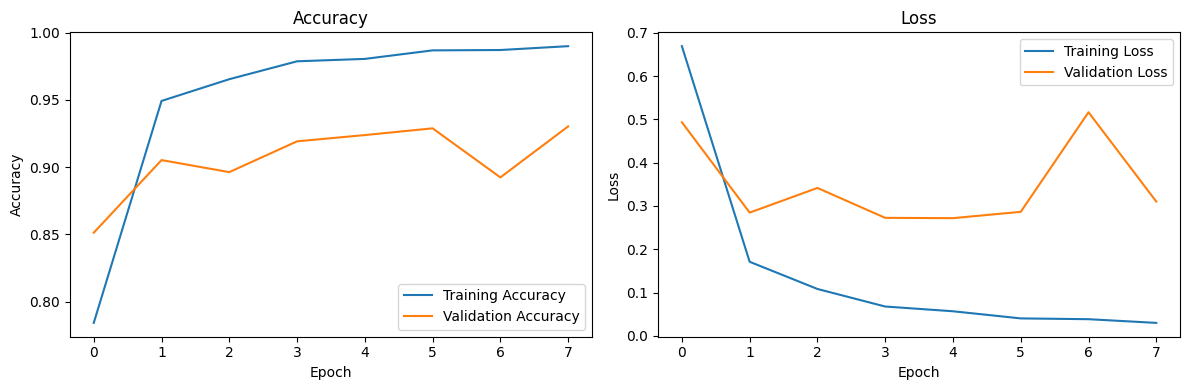

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

These plots visualize the training history, showing the model's accuracy and loss over each epoch for both the training and validation datasets. This helps in identifying potential overfitting (when training accuracy/loss continues to improve but validation accuracy/loss plateaus or worsens).

In [ ]:
y_pred = model.predict(test_datagen)
y_pred_class = np.argmax(y_pred, axis=1)

88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


This cell generates predictions for the test dataset using the trained model. `model.predict(test_datagen)` outputs probability distributions for each class, and `np.argmax` is used to convert these probabilities into the predicted class labels (the digit with the highest probability).

In [ ]:
y_true = test_datagen.classes
class_labels = list(train_datagen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_class)

Here, the true labels for the test dataset are extracted from `test_datagen.classes`. The `confusion_matrix` is then computed by comparing the true labels (`y_true`) with the predicted labels (`y_pred_class`), providing a detailed breakdown of correct and incorrect classifications for each digit.

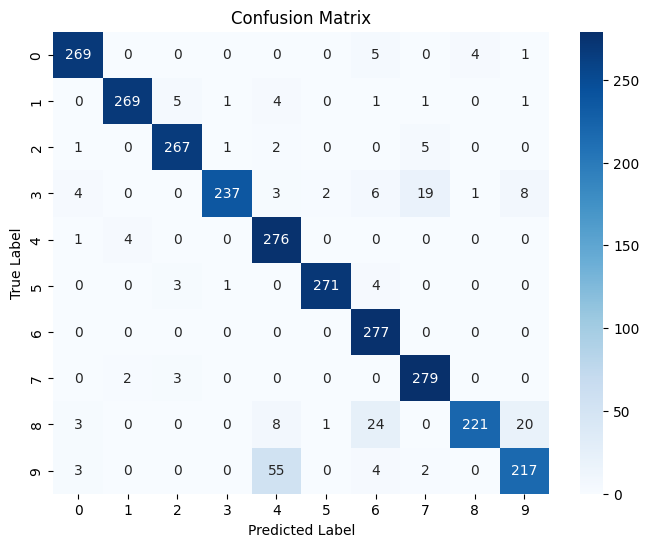

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

This cell visualizes the confusion matrix as a heatmap using `seaborn`. The heatmap clearly shows how many times each digit was correctly classified and how often it was misclassified as another digit. The rows represent the true labels, and the columns represent the predicted labels.

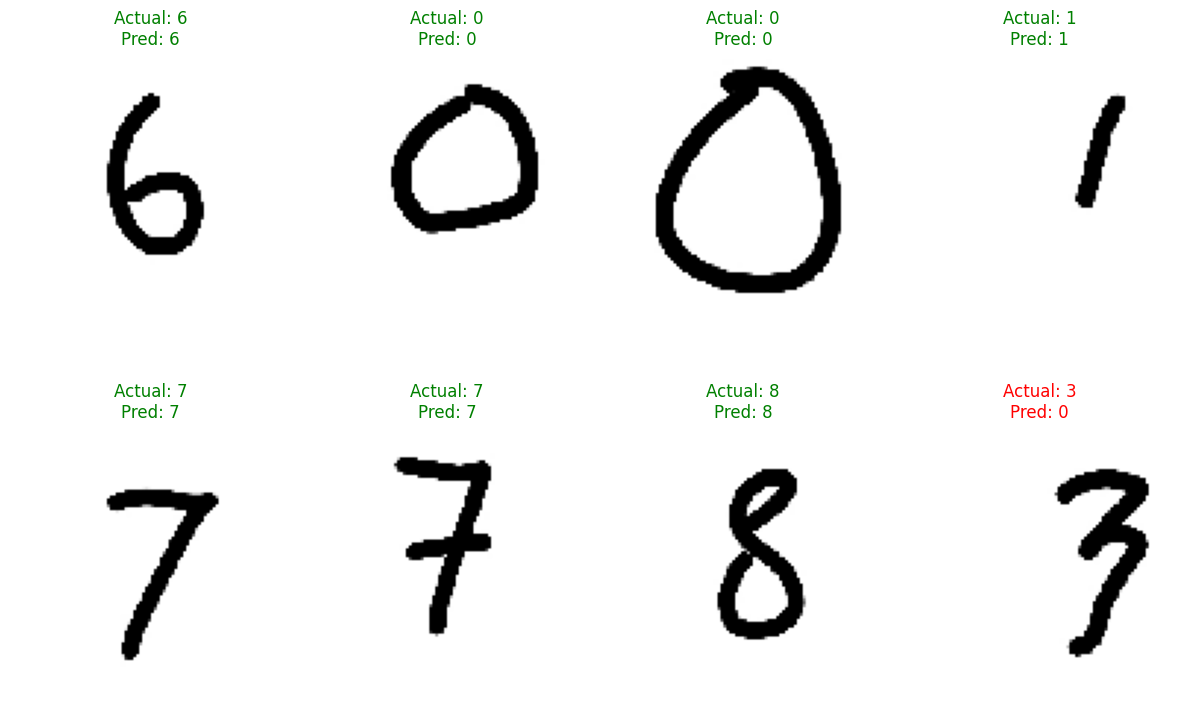

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

indices = random.sample(range(len(test_datagen.filepaths)), 8)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
    img_path = test_datagen.filepaths[idx]
    img = image.load_img(
        img_path,
        color_mode='grayscale',
        target_size=(96,96)
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    predicted = np.argmax(prediction)
    actual = test_datagen.classes[idx]
    plt.subplot(2,4,i+1)
    plt.imshow(img_array[0].squeeze(), cmap='gray')

    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPred: {predicted}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

This final cell provides a visual inspection of the model's predictions on a random sample of 8 images from the test set. It displays each image along with its actual label and the model's predicted label, highlighting correct predictions in green and incorrect ones in red. This offers an intuitive understanding of the model's performance on individual examples.